Import and load the datasets

This cell imports necessary libraries like pandas, numpy, and matplotlib, and then loads the training and testing datasets from CSV files.


In [ ]:
# Import libraries and load the training and testing datasets.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
train = pd.read_csv("/content/dataset_A_training.csv")
test = pd.read_csv("/content/dataset_A_testing.csv")

TARGET = "seasonal_vaccine"

This cell displays the dimensions, initial rows, and data types of the loaded training dataset for a quick overview.

In [ ]:
# Display the shape and first few rows of the training dataset, along with column data types.
print("Training dataset shape:", train.shape)
print("Testing dataset shape:", test.shape)

print("\nFirst five rows:")
display(train.head())

print("\nColumn data types:")
display(train.dtypes)

Training dataset shape: (4756, 31)
Testing dataset shape: (4749, 30)

First five rows:


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0



Column data types:


,0
respondent_id,int64
flu_concern,float64
flu_knowledge,float64
behavioral_antiviral_meds,float64
behavioral_avoidance,float64
behavioral_face_mask,float64
behavioral_wash_hands,float64
behavioral_large_gatherings,float64
behavioral_outside_home,float64
behavioral_touch_face,float64


 Target variable

 This cell analyzes the distribution of the target variable 'seasonal_vaccine' and visualizes it using a bar plot to show vaccination uptake.


Target distribution:
                  Count  Percentage
seasonal_vaccine                   
1                  2551       53.64
0                  2205       46.36


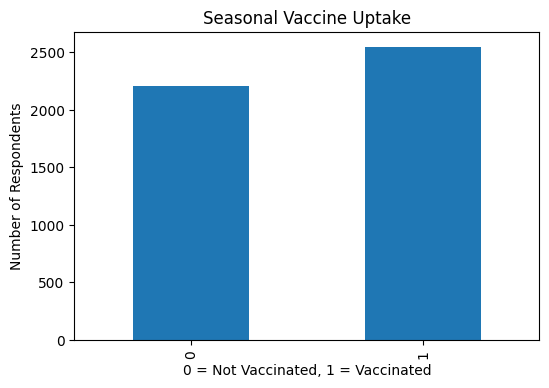

In [ ]:
# Analyze the distribution of the target variable 'seasonal_vaccine' and visualize it with a bar plot.
target_counts = train[TARGET].value_counts()
target_percent = train[TARGET].value_counts(normalize=True) * 100

print("\nTarget distribution:")
print(pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
}))

plt.figure(figsize=(6,4))
train[TARGET].value_counts().sort_index().plot(kind="bar")
plt.title("Seasonal Vaccine Uptake")
plt.xlabel("0 = Not Vaccinated, 1 = Vaccinated")
plt.ylabel("Number of Respondents")
plt.show()

Missing value prediction

This cell calculates and visualizes the percentage of missing values for each feature in the training dataset

,Missing Count,Missing Percentage
employment_sector,2314,48.65
health_insurance,1925,40.48
income_poverty,790,16.61
rent_or_own,381,8.01
doctor_recc_seasonal,321,6.75
education,270,5.68
employment_status,269,5.66
marital_status,265,5.57
chronic_med_condition,188,3.95
child_under_6_months,152,3.20


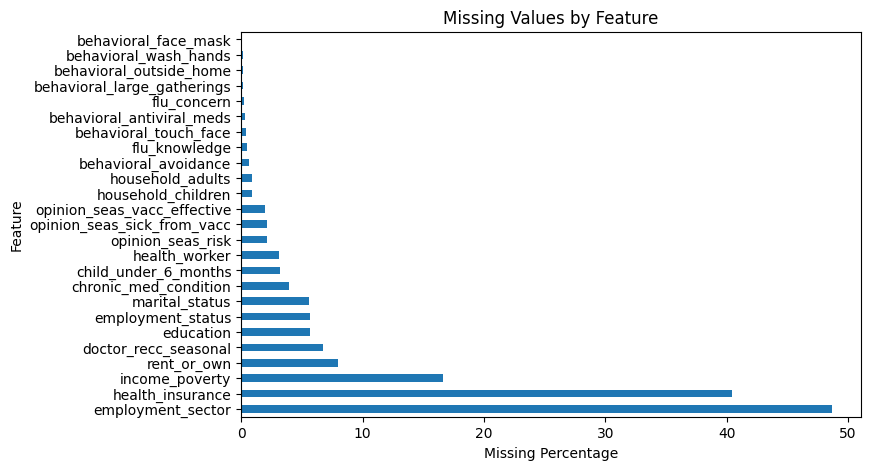

In [ ]:
# Calculate and visualize the percentage of missing values for each feature in the training dataset.
missing = train.isnull().sum()
missing_pct = (missing / len(train)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_pct.round(2)
}).sort_values(by="Missing Percentage", ascending=False)

display(missing_df[missing_df["Missing Count"] > 0])

plt.figure(figsize=(8,5))
missing_df[missing_df["Missing Count"] > 0]["Missing Percentage"].plot(kind="barh")
plt.title("Missing Values by Feature")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.show()

Vaccination rate by doctor recommendation

This cell calculates and displays the vaccination rate based on whether a doctor recommended the seasonal vaccine, and visualizes this relationship with a bar plot.

,seasonal_vaccine
doctor_recc_seasonal,
0.0,41.036717
1.0,77.549789


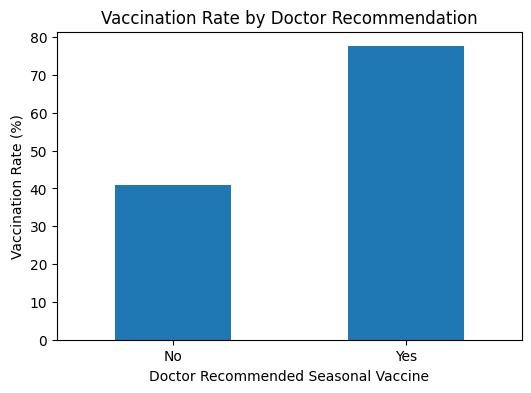

In [ ]:
# Calculate and display the vaccination rate based on doctor recommendations, and visualize it with a bar plot.
doctor_rate = train.groupby("doctor_recc_seasonal")[TARGET].mean() * 100

display(doctor_rate)

plt.figure(figsize=(6,4))
doctor_rate.plot(kind="bar")
plt.title("Vaccination Rate by Doctor Recommendation")
plt.xlabel("Doctor Recommended Seasonal Vaccine")
plt.ylabel("Vaccination Rate (%)")
plt.xticks([0,1], ["No", "Yes"], rotation=0)
plt.show()

Vaccination rate by belief in vaccine effectiveness

This cell calculates and displays the vaccination rate based on respondents' opinions about seasonal vaccine effectiveness, and visualizes this with a bar plot.

,seasonal_vaccine
opinion_seas_vacc_effective,
1.0,24.401914
2.0,16.809117
3.0,35.602094
4.0,44.558522
5.0,74.936322


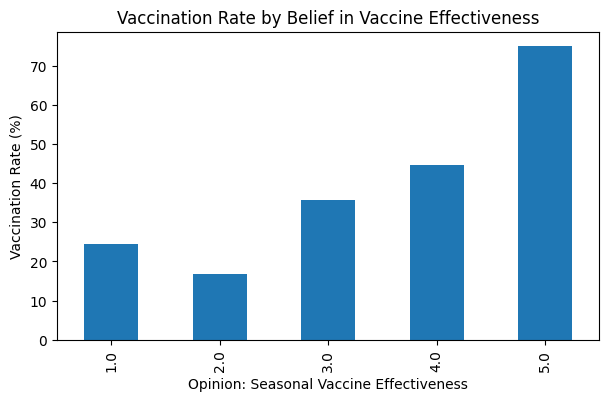

In [ ]:
# Calculate and display the vaccination rate based on belief in vaccine effectiveness, and visualize it with a bar plot.

effectiveness_rate = train.groupby("opinion_seas_vacc_effective")[TARGET].mean() * 100

display(effectiveness_rate)

plt.figure(figsize=(7,4))
effectiveness_rate.plot(kind="bar")
plt.title("Vaccination Rate by Belief in Vaccine Effectiveness")
plt.xlabel("Opinion: Seasonal Vaccine Effectiveness")
plt.ylabel("Vaccination Rate (%)")
plt.show()

Vaccination rate by perceived flu risk

This cell calculates and displays the vaccination rate based on how respondents perceive the risk of seasonal flu, and visualizes this with a bar plot.

,seasonal_vaccine
opinion_seas_risk,
1.0,24.382385
2.0,43.451981
3.0,67.500000
4.0,71.310345
5.0,78.614458


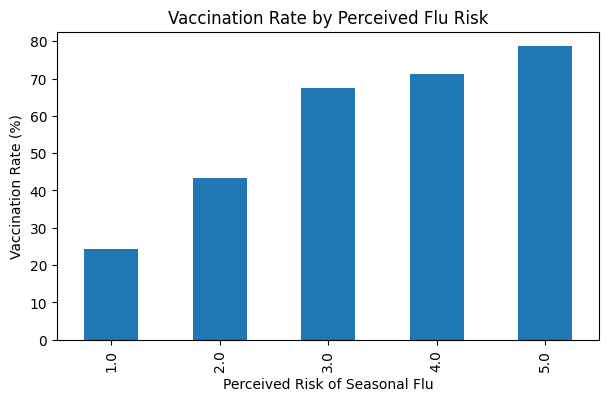

In [ ]:
# Calculate and display the vaccination rate based on perceived flu risk, and visualize it with a bar plot.
risk_rate = train.groupby("opinion_seas_risk")[TARGET].mean() * 100

display(risk_rate)

plt.figure(figsize=(7,4))
risk_rate.plot(kind="bar")
plt.title("Vaccination Rate by Perceived Flu Risk")
plt.xlabel("Perceived Risk of Seasonal Flu")
plt.ylabel("Vaccination Rate (%)")
plt.show()

Vaccination rate by age group


This cell calculates and displays the vaccination rate across different age groups and visualizes the results with a bar plot.

,seasonal_vaccine
age_group,
18 - 34 Years,34.895833
35 - 44 Years,42.611191
45 - 54 Years,49.731472
55 - 64 Years,60.860861
65+ Years,72.540633


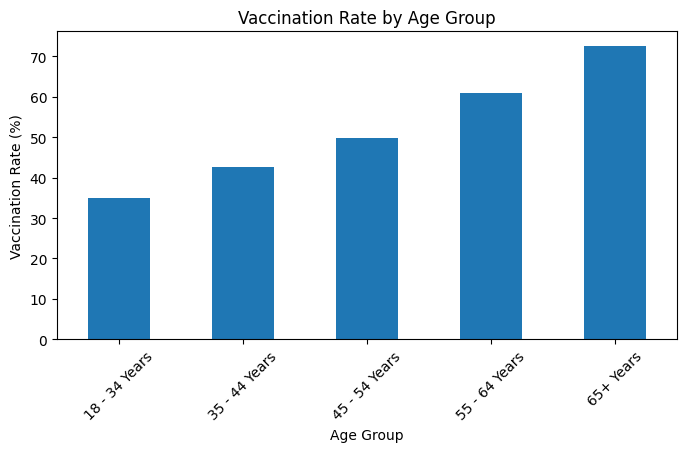

In [ ]:
# Calculate and display the vaccination rate by age group, and visualize it with a bar plot.


age_rate = train.groupby("age_group")[TARGET].mean() * 100

display(age_rate)

plt.figure(figsize=(8,4))
age_rate.plot(kind="bar")
plt.title("Vaccination Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Vaccination Rate (%)")
plt.xticks(rotation=45)
plt.show()

 Vaccination rate by health worker status

This cell calculates and displays the vaccination rate specifically for healthcare workers compared to non-healthcare workers, visualized with a bar plot.

,seasonal_vaccine
health_worker,
0.0,51.10664
1.0,72.74168


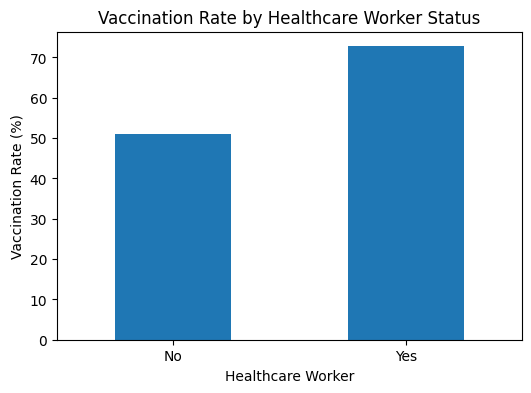

In [ ]:
# Calculate and display the vaccination rate for healthcare workers, and visualize it with a bar plot.


health_worker_rate = train.groupby("health_worker")[TARGET].mean() * 100

display(health_worker_rate)

plt.figure(figsize=(6,4))
health_worker_rate.plot(kind="bar")
plt.title("Vaccination Rate by Healthcare Worker Status")
plt.xlabel("Healthcare Worker")
plt.ylabel("Vaccination Rate (%)")
plt.xticks([0,1], ["No", "Yes"], rotation=0)
plt.show()

Behavioural prevention practices

This cell analyzes and displays how different behavioral prevention practices correlate with vaccination rates, and visualizes the differences in uptake.

,Behaviour,Vaccination Rate if No,Vaccination Rate if Yes,Difference
3,behavioral_wash_hands,40.077320,56.294058,16.216739
6,behavioral_touch_face,44.918699,57.651027,12.732328
1,behavioral_avoidance,45.700637,56.430219,10.729582
2,behavioral_face_mask,53.089505,60.683761,7.594256
5,behavioral_outside_home,51.984757,56.883605,4.898847
4,behavioral_large_gatherings,51.826029,56.714697,4.888668
0,behavioral_antiviral_meds,53.849577,49.193548,-4.656029


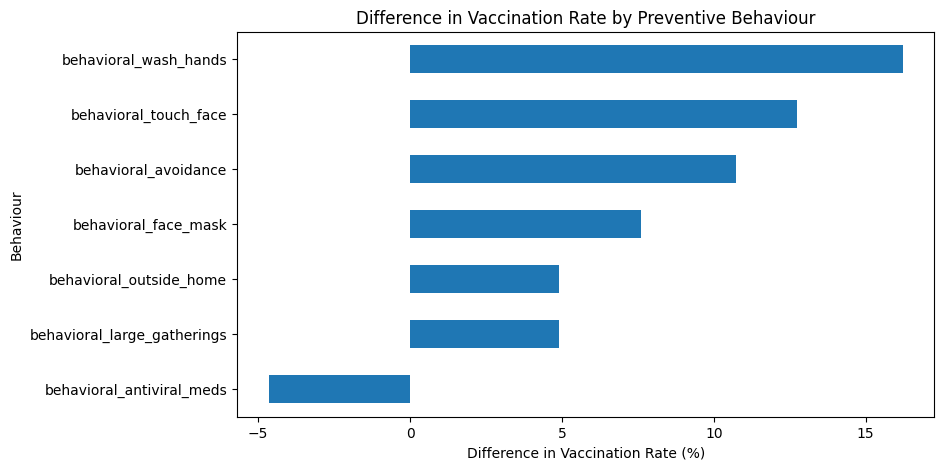

In [ ]:
# Analyze the difference in vaccination rates based on various behavioral prevention practices.


behaviour_cols = [
    "behavioral_antiviral_meds",
    "behavioral_avoidance",
    "behavioral_face_mask",
    "behavioral_wash_hands",
    "behavioral_large_gatherings",
    "behavioral_outside_home",
    "behavioral_touch_face"
]

behaviour_results = []

for col in behaviour_cols:
    if col in train.columns:
        rate = train.groupby(col)[TARGET].mean() * 100
        behaviour_results.append({
            "Behaviour": col,
            "Vaccination Rate if No": rate.get(0, np.nan),
            "Vaccination Rate if Yes": rate.get(1, np.nan),
            "Difference": rate.get(1, np.nan) - rate.get(0, np.nan)
        })

behaviour_df = pd.DataFrame(behaviour_results)
display(behaviour_df.sort_values(by="Difference", ascending=False))

plt.figure(figsize=(9,5))
behaviour_df.set_index("Behaviour")["Difference"].sort_values().plot(kind="barh")
plt.title("Difference in Vaccination Rate by Preventive Behaviour")
plt.xlabel("Difference in Vaccination Rate (%)")
plt.ylabel("Behaviour")
plt.show()

Correlation with target

This cell calculates and displays the top 15 numerical features most correlated with the target variable, visualizing their correlation strengths with a bar plot.

,seasonal_vaccine
opinion_seas_risk,0.393312
opinion_seas_vacc_effective,0.357129
doctor_recc_seasonal,0.354831
health_insurance,0.235809
chronic_med_condition,0.166391
flu_concern,0.163732
flu_knowledge,0.155676
health_worker,0.149263
household_children,-0.127039
behavioral_wash_hands,0.120247


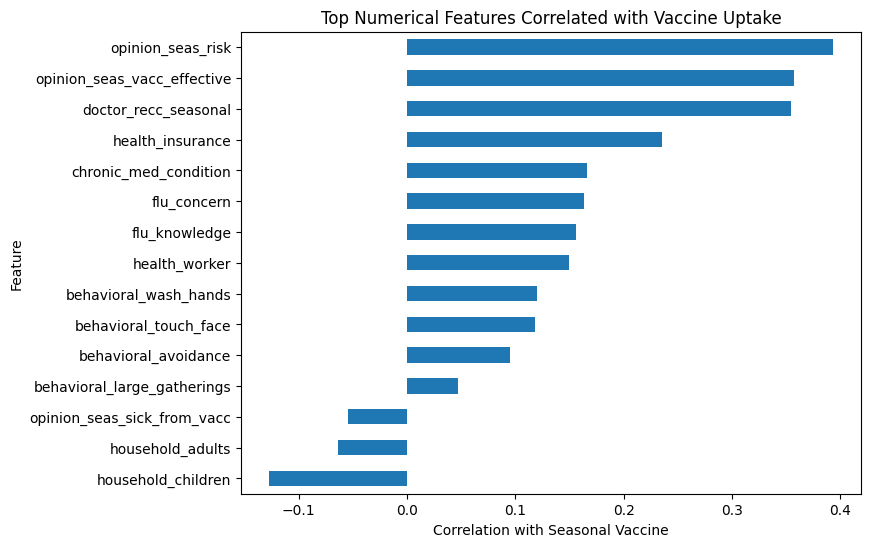

In [ ]:
# Calculate and display the top 15 numerical features correlated with the target variable, and visualize them with a bar plot.


numeric_cols = train.select_dtypes(include=np.number).columns

corr = train[numeric_cols].corr()[TARGET].drop(TARGET)
corr = corr.sort_values(key=abs, ascending=False)

display(corr.head(15))

plt.figure(figsize=(8,6))
corr.head(15).sort_values().plot(kind="barh")
plt.title("Top Numerical Features Correlated with Vaccine Uptake")
plt.xlabel("Correlation with Seasonal Vaccine")
plt.ylabel("Feature")
plt.show()

Simple summary table

This cell creates and displays a summary table that explains the relevance of various exploratory data analysis (EDA) areas.

In [ ]:
# Create and display a summary table for various EDA areas, outlining their relevance.


summary_table = pd.DataFrame({
    "EDA Area": [
        "Target distribution",
        "Missing values",
        "Doctor recommendation",
        "Vaccine effectiveness belief",
        "Perceived flu risk",
        "Age group",
        "Healthcare worker status",
        "Preventive behaviours"
    ],
    "Why it matters": [
        "Shows whether the model is learning from balanced groups.",
        "Highlights variables needing imputation or missing-value handling.",
        "Shows the influence of healthcare professionals on vaccine uptake.",
        "Captures trust and confidence in vaccination.",
        "Shows whether perceived vulnerability affects behaviour.",
        "Identifies demographic differences in vaccine uptake.",
        "Shows whether occupational exposure influences uptake.",
        "Shows whether vaccination is linked to broader health-conscious behaviour."
    ]
})

display(summary_table)

,EDA Area,Why it matters
0,Target distribution,Shows whether the model is learning from balan...
1,Missing values,Highlights variables needing imputation or mis...
2,Doctor recommendation,Shows the influence of healthcare professional...
3,Vaccine effectiveness belief,Captures trust and confidence in vaccination.
4,Perceived flu risk,Shows whether perceived vulnerability affects ...
5,Age group,Identifies demographic differences in vaccine ...
6,Healthcare worker status,Shows whether occupational exposure influences...
7,Preventive behaviours,Shows whether vaccination is linked to broader...



 DATA PREPROCESSING

This cell imports essential libraries required for data preprocessing and machine learning model development.

In [ ]:
# Import necessary libraries for data preprocessing and machine learning.

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

Load Dataset

This cell loads the raw training and testing datasets into pandas DataFrames for subsequent processing.
This cell performs basic checks by printing the shapes of the training and testing datasets, showing the first few rows of the training data, and displaying its column information.

In [ ]:
# Load the training and testing datasets into pandas DataFrames.

train_df = pd.read_csv("dataset_A_training.csv")
test_df = pd.read_csv("dataset_A_testing.csv")

In [ ]:
# Display the shapes of the training and testing datasets, and show the first few rows of the training data along with its info.
# Basic check
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print(train_df.head())
print(train_df.info())

Training shape: (4756, 31)
Testing shape: (4749, 30)
   respondent_id  flu_concern  flu_knowledge  behavioral_antiviral_meds  \
0              1          2.0            0.0                        0.0   
1              2          1.0            1.0                        0.0   
2              3          2.0            1.0                        0.0   
3              4          1.0            2.0                        0.0   
4              5          2.0            2.0                        0.0   

   behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
0                   1.0                   0.0                    1.0   
1                   1.0                   0.0                    0.0   
2                   1.0                   0.0                    1.0   
3                   1.0                   0.0                    1.0   
4                   1.0                   0.0                    1.0   

   behavioral_large_gatherings  behavioral_outside_home  \
0   

Remove duplicate rows

This cell removes any duplicate rows present in the training dataset to ensure data quality and prevent redundancy.

In [ ]:
# Remove duplicate rows from the training dataset.

train_df = train_df.drop_duplicates()

 Identify target column

This cell defines the target variable, separates the features from the target in the training data, and stores the respondent IDs from the test set.

In [ ]:
# Define the target column and separate features (X) from the target variable (y).
target_col = TARGET

# Drop 'respondent_id' from features as it's an identifier, not a predictive feature.
X = train_df.drop(columns=[target_col, "respondent_id"])
y = train_df[target_col]

# Store respondent_ids from the test set for submission later
test_ids = test_df["respondent_id"]
# Drop 'respondent_id' from the test features for prediction
test_df_features = test_df.drop(columns=["respondent_id"])

 Separate numerical and categorical columns

This cell identifies and categorizes features into numerical and categorical types from the feature set.

In [ ]:
# Identify and print the numerical and categorical columns from the feature set (X).

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns

print("Numerical columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))

Numerical columns: ['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']
Categorical columns: ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [ ]:
# Encode the target variable if it is categorical using LabelEncoder.
# Encode target if it is categorical
if y.dtype == "object" or y.dtype.name == "category":
    le = LabelEncoder()
    y = le.fit_transform(y)

Preprocessing for numeric columns

This cell defines a preprocessing pipeline for numerical features that includes imputing missing values with the median and scaling the data using StandardScaler.

In [ ]:
# Define a preprocessing pipeline for numerical columns including imputation and scaling.

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

 Preprocessing for categorical columns

This cell defines a preprocessing pipeline for categorical features, which involves imputing missing values with the most frequent category and converting categorical features into numerical format using OneHotEncoder.

In [ ]:
# Define a preprocessing pipeline for categorical columns including imputation and one-hot encoding.

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


Combine preprocessing

This cell integrates the numerical and categorical preprocessing steps into a single ColumnTransformer for unified data transformation.

In [ ]:
# Combine numerical and categorical preprocessing steps into a single ColumnTransformer.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

Train-validation split

This cell partitions the training data into separate training and validation sets to evaluate model performance effectively.
This cell applies the defined preprocessor to the training data to fit it and then transforms both the training and validation sets.

In [ ]:
# Split the training data into training and validation sets for model evaluation.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if len(np.unique(y)) < 20 else None
)

In [ ]:
# Fit the preprocessor on the training data and transform both training and validation sets.
# Fit preprocessing on training data only
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

Process test dataset

This cell transforms the test dataset using the previously fitted preprocessor and then prints the shapes of all processed datasets.

In [ ]:
# Transform the test dataset using the fitted preprocessor and print the shapes of the processed datasets.

X_test_processed = preprocessor.transform(test_df_features)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (3804, 68)
Processed validation shape: (952, 68)
Processed test shape: (4749, 68)


 Model Building

This cell initializes a LightGBM classifier and constructs a machine learning pipeline that incorporates both the preprocessing steps and the LightGBM model.

In [ ]:
# Define the LightGBM classifier model and create a pipeline that includes the preprocessor and the model.

# LightGBM model
lgbm_model = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.85,
    colsample_bytree=0.85,
    class_weight="balanced",
    random_state=42
)

# Pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", lgbm_model)
])


Training the model

This cell trains the complete machine learning pipeline using the preprocessed training data.

In [ ]:
# Train the complete pipeline on the training data.

pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 2040, number of negative: 1764
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001145 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 163
[LightGBM] [Info] Number of data points in the train set: 3804, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_hom...
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'census_msa',
       'employment_sector'],
      dtype='object'))])),
                ('model',
                 LGBMClassifier(class_weight='balanced', colsample_bytree=0.85,
                                learning_rate=0.03, n_estimators=800,
                                random_state=42, subsample=0.85))])

Validating the model

This cell makes predictions on the validation set using the trained pipeline and assesses the model's performance by calculating the F1 score and generating a classification report.

In [ ]:
# Make predictions on the validation set and evaluate the model's performance using the F1 score and a classification report.
y_pred = pipeline.predict(X_val)

f1 = f1_score(y_val, y_pred)

print("LightGBM F1 Score:", round(f1, 4))
print(classification_report(y_val, y_pred))

LightGBM F1 Score: 0.7784
              precision    recall  f1-score   support

           0       0.74      0.77      0.75       441
           1       0.79      0.76      0.78       511

    accuracy                           0.77       952
   macro avg       0.77      0.77      0.77       952
weighted avg       0.77      0.77      0.77       952



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Train on full dataset

This cell retrains the machine learning pipeline using the entire training dataset (features and target) to build the final model.

In [ ]:
# Train the pipeline on the full dataset (X and y) for final model training.

pipeline.fit(X, y)

[LightGBM] [Info] Number of positive: 2551, number of negative: 2205
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002157 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 167
[LightGBM] [Info] Number of data points in the train set: 4756, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_hom...
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'census_msa',
       'employment_sector'],
      dtype='object'))])),
                ('model',
                 LGBMClassifier(class_weight='balanced', colsample_bytree=0.85,
                                learning_rate=0.03, n_estimators=800,
                                random_state=42, subsample=0.85))])

Predict test data

This cell generates predictions on the unseen test dataset using the fully trained pipeline.

In [ ]:
# Generate predictions on the test dataset using the trained pipeline.
test_predictions = pipeline.predict(test_df_features)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Creating the  Submission file

This cell creates a submission file by combining the test respondent IDs with the model's predictions and saves it as a CSV file.

In [ ]:
# Create a submission DataFrame with respondent IDs and predicted seasonal vaccine values, then save it to a CSV file.

submission = pd.DataFrame({
    "respondent_id": test_ids,
    "seasonal_vaccine": test_predictions
})

submission.to_csv("submission_lightgbm.csv", index=False)

print("Submission file created: submission_lightgbm.csv")

Submission file created: submission_lightgbm.csv


Hyperparameter Tuning

This cell imports libraries for hyperparameter tuning, sets up a LightGBM model and pipeline, and defines a grid of hyperparameters for RandomizedSearchCV.
This cell trains the RandomizedSearchCV model on the training data to find the best hyperparameters, then prints the optimal parameters and their corresponding F1 score.
This cell extracts the best performing model pipeline found during the RandomizedSearchCV process.
This cell uses the best tuned LightGBM model to make predictions on the test dataset and generates a new submission file.

In [ ]:
# Import necessary libraries for hyperparameter tuning and define a LightGBM model, a pipeline, and a hyperparameter search grid for RandomizedSearchCV.

from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, f1_score
import numpy as np
from sklearn.pipeline import Pipeline

# Base model (without direct fit)
lgbm = LGBMClassifier(
    objective="binary",   # change to "multiclass" if target has more than 2 classes
    random_state=42,
    class_weight="balanced"
)

# Create a pipeline for RandomizedSearchCV
pipeline_for_tuning = Pipeline(steps=[
    ('preprocessor', preprocessor), # Use the already defined preprocessor
    ('model', lgbm)
])

# Hyperparameter search space, prefixed with 'model__' for pipeline steps
param_grid = {
    "model__n_estimators": [100, 200, 300, 500, 800],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves": [15, 31, 50, 70, 100],
    "model__max_depth": [-1, 3, 5, 7, 10],
    "model__min_child_samples": [10, 20, 30, 50, 80],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [0, 0.01, 0.1, 1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline_for_tuning, # Use the pipeline here
    param_distributions=param_grid,
    n_iter=50,
    scoring="f1",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Train the RandomizedSearchCV model on the training data and print the best parameters and corresponding F1 score.
# Train tuning model
random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("Best CV F1 Score:")
print(random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Number of positive: 2040, number of negative: 1764
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001598 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 169
[LightGBM] [Info] Number of data points in the train set: 3804, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Best Parameters:
{'model__subsample': 0.6, 'model__reg_lambda': 0.1, 'model__reg_alpha': 0.1, 'model__num_leaves': 70, 'model__n_estimators': 300, 'model__min_child_samples': 10, 'model__max_depth': 10, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}
Best CV F1 Score:
0.7846187194897704


In [ ]:
# Extract the best estimator (model pipeline) from the RandomizedSearchCV results.
# Best model
best_lgbm = random_search.best_estimator_

In [ ]:
# Make predictions on the test set using the best tuned LightGBM model, and create and save a submission file.
# Prediction
y_pred = best_lgbm.predict(test_df_features)

# 'test_ids' is already defined in the preprocessing step
# Create submission file
submission = pd.DataFrame({
    "respondent_id": test_ids,
    "seasonal_vaccine": y_pred
})

submission.to_csv("submission_tuned_lgbm.csv", index=False)

print("Submission file created: submission_tuned_lgbm.csv")

Submission file created: submission_tuned_lgbm.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Performance Analysis

This cell imports various evaluation metrics and plotting libraries, then uses the best tuned model to make predictions and calculate probabilities on the validation set.
This cell calculates and prints several key performance metrics (accuracy, precision, recall, F1-score, ROC-AUC) and a detailed classification report for the tuned model on the validation set.

In [ ]:
# Import necessary metrics and plotting libraries, then make predictions and calculate probabilities on the validation set using the best tuned model.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions on the validation set using the best tuned pipeline
y_pred = best_lgbm.predict(X_val)

# If probabilities are available
try:
    y_prob = best_lgbm.predict_proba(X_val)[:, 1]
except:
    y_prob = None

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Calculate and print various performance metrics (accuracy, precision, recall, F1-score, ROC-AUC) and the classification report for the tuned model on the validation set.
# Metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='weighted')
recall = recall_score(y_val, y_pred, average='weighted')
f1 = f1_score(y_val, y_pred, average='weighted')

print("="*50)
print("MODEL PERFORMANCE ON VALIDATION SET (TUNED MODEL)")
print("="*50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

if y_prob is not None:
    try:
        roc_auc = roc_auc_score(y_val, y_prob)
        print(f"ROC-AUC  : {roc_auc:.4f}")
    except:
        pass

print("\nClassification Report")
print(classification_report(y_val, y_pred))

MODEL PERFORMANCE ON VALIDATION SET (TUNED MODEL)
Accuracy : 0.7668
Precision: 0.7680
Recall   : 0.7668
F1 Score : 0.7671
ROC-AUC  : 0.8431

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.77      0.75       441
           1       0.79      0.76      0.78       511

    accuracy                           0.77       952
   macro avg       0.77      0.77      0.77       952
weighted avg       0.77      0.77      0.77       952



 Confusion Matrix

This cell generates and displays a confusion matrix as a heatmap to visually represent the tuned model's performance on the validation set.

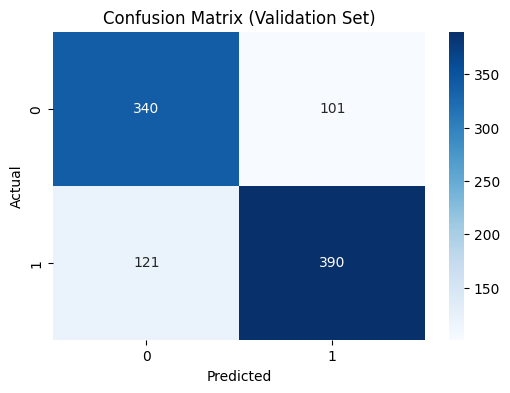

In [ ]:
# Generate and display a confusion matrix heatmap for the tuned model's predictions on the validation set.

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.title('Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Cross Validation F1 Score

This cell performs cross-validation to assess the robustness of the best tuned LightGBM model, printing individual F1 scores and their mean.

In [ ]:
# Perform cross-validation to calculate and print the F1 scores and their mean for the best tuned LightGBM model on the training data.

from sklearn.model_selection import cross_val_score

cv_f1 = cross_val_score(
    best_lgbm, # Use the pipeline that includes preprocessing
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted'
)

print("CV F1 Scores:", cv_f1)
print("Mean CV F1:", cv_f1.mean())

[LightGBM] [Info] Number of positive: 1632, number of negative: 1411
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000989 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 169
[LightGBM] [Info] Number of data points in the train set: 3043, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1632, number of negative: 1411
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000944 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 169
[LightGBM] [Info] Number of data points in the train set: 3043, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1632, number of negative: 1411
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000934 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 167
[LightGBM] [Info] Number of data points in the train set: 3043, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1632, number of negative: 1411
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000943 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 169
[LightGBM] [Info] Number of data points in the train set: 3043, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1632, number of negative: 1412
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000977 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 169
[LightGBM] [Info] Number of data points in the train set: 3044, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
CV F1 Scores: [0.72949709 0.79371184 0.75967607 0.76884326 0.79501436]
Mean CV F1: 0.7693485238800571


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
